✅ Sentinel Hub configuration loaded
   Base URL: https://sh.dataspace.copernicus.eu
🛰️  Arctic Satellite Imagery Fetcher
Available regions:
  • svalbard        - Svalbard Archipelago
  • north_norway    - Northern Norway
  • kola_murmansk   - Kola Peninsula & Murmansk
  • barents_sea     - Central Barents Sea
  • full_arctic     - Full Arctic Coverage

🗺️  Svalbard Archipelago
    🇳🇴 Norwegian Arctic archipelago
    Bounds: 10.0°E to 35.0°E, 76.0°N to 81.0°N

📡 Fetching Sentinel-2 L2A (Optical) for Svalbard Archipelago...
   Time range: 2025-08-20 to 2025-09-19
   Image size: 2000×1500 pixels
✅ Successfully downloaded (1500, 2000, 3)
💾 Saved: Svalbard_Archipelago_S2_20250919_113459.png


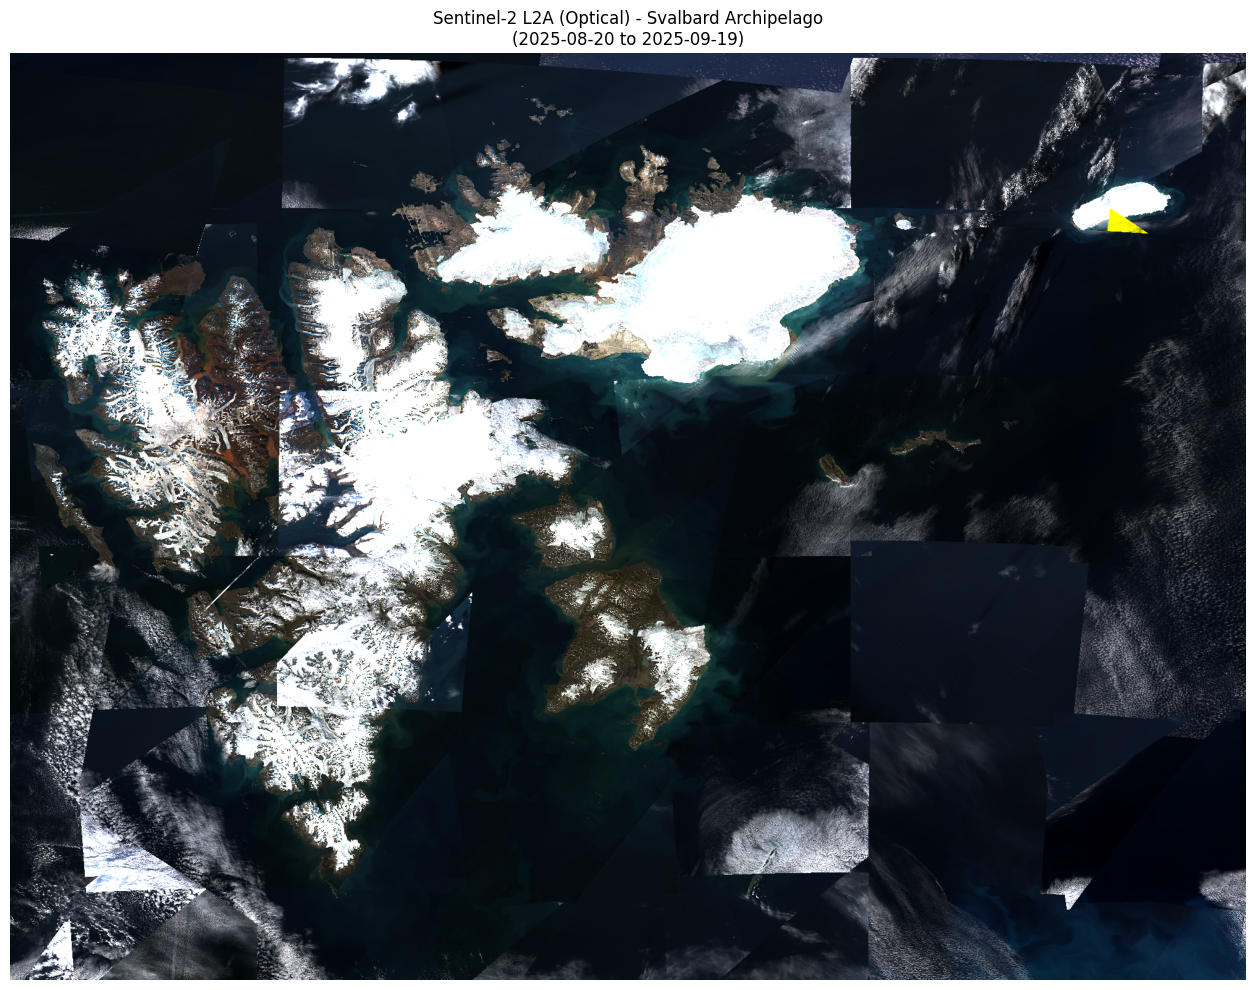


📡 Fetching Sentinel-1 IW (SAR) for Svalbard Archipelago...
   Time range: 2025-08-20 to 2025-09-19
   Image size: 2000×1500 pixels
✅ Successfully downloaded (1500, 2000)
💾 Saved: Svalbard_Archipelago_S1_20250919_113502.png


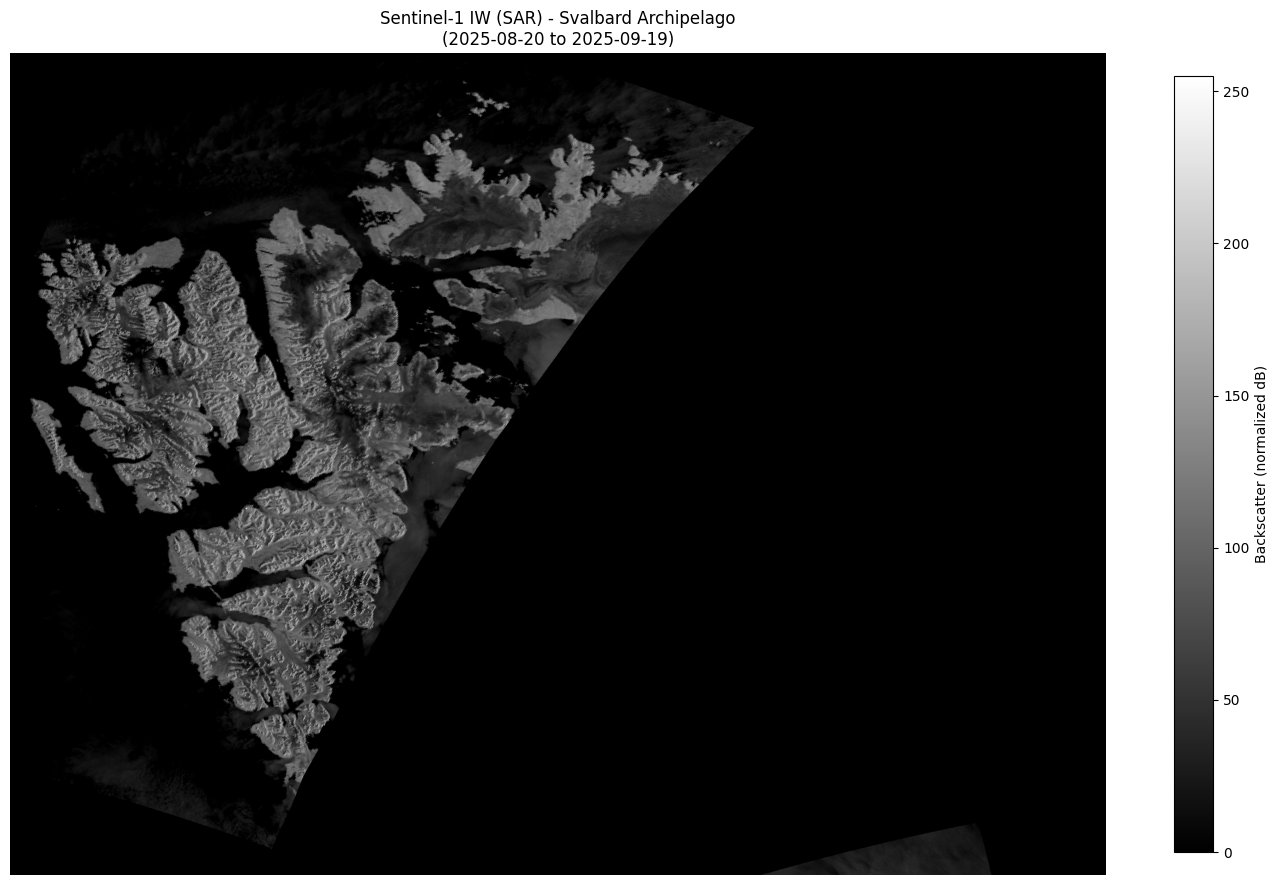


🗺️  Northern Norway
    🇳🇴 Finnmark and northern Troms counties
    Bounds: 15.0°E to 32.0°E, 68.0°N to 71.5°N

📡 Fetching Sentinel-2 L2A (Optical) for Northern Norway...
   Time range: 2025-08-20 to 2025-09-19
   Image size: 2000×1500 pixels
✅ Successfully downloaded (1500, 2000, 3)
💾 Saved: Northern_Norway_S2_20250919_113507.png


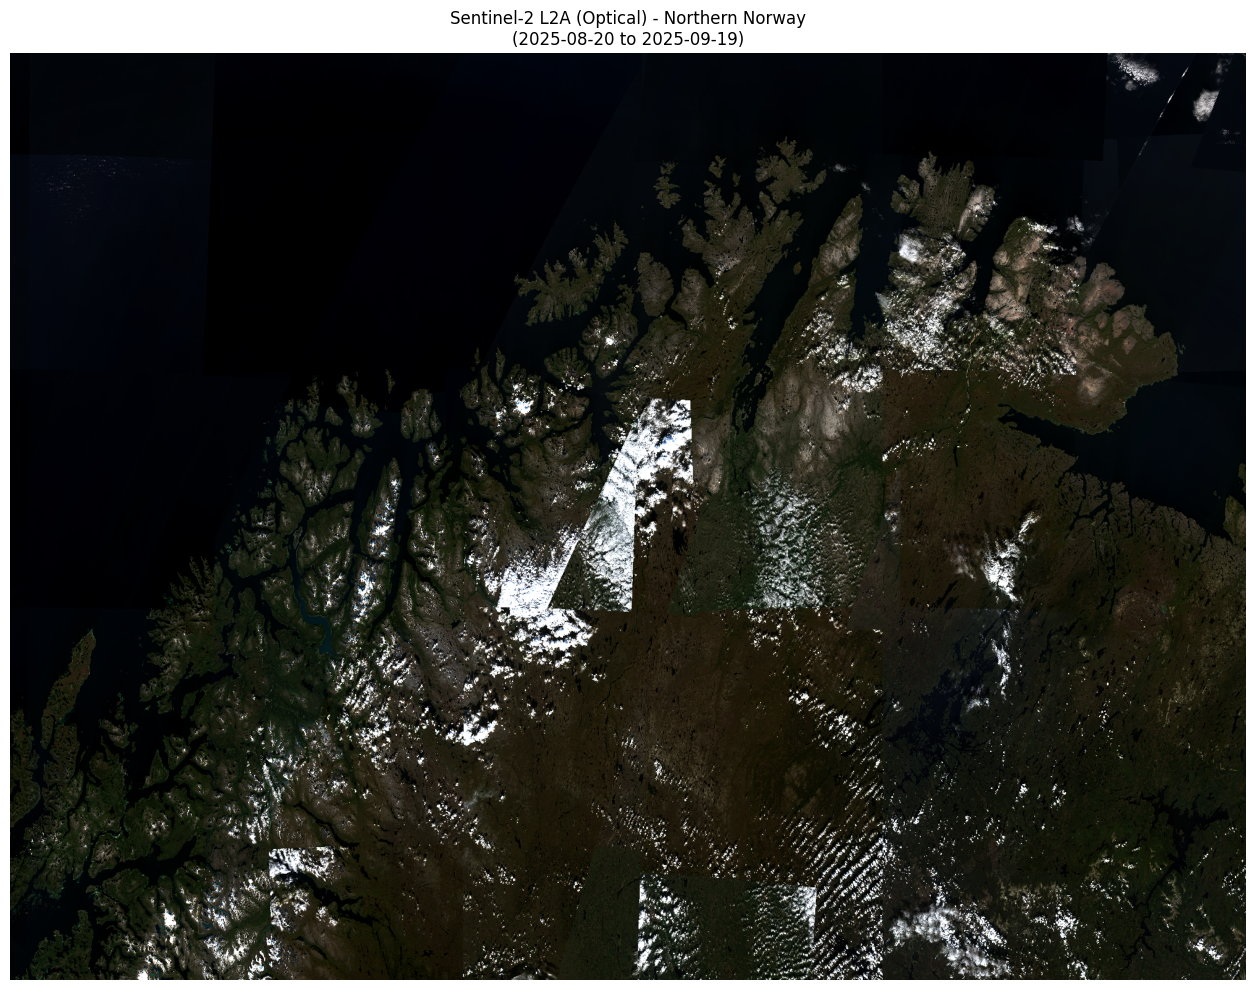


📡 Fetching Sentinel-1 IW (SAR) for Northern Norway...
   Time range: 2025-08-20 to 2025-09-19
   Image size: 2000×1500 pixels
✅ Successfully downloaded (1500, 2000)
💾 Saved: Northern_Norway_S1_20250919_113511.png


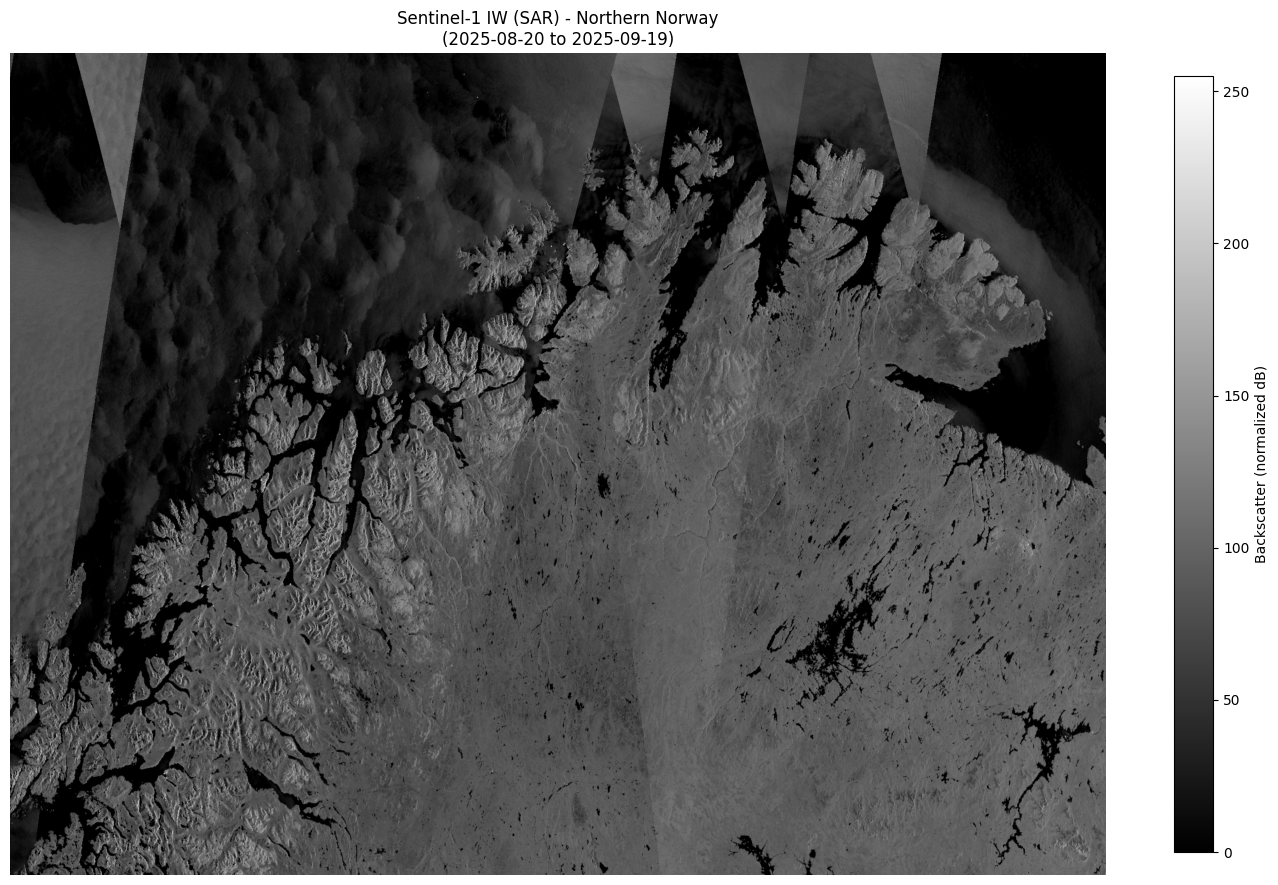


🗺️  Kola Peninsula & Murmansk
    🇷🇺 Russian Arctic region with naval bases
    Bounds: 28.0°E to 42.0°E, 67.5°N to 70.0°N

📡 Fetching Sentinel-2 L2A (Optical) for Kola Peninsula & Murmansk...
   Time range: 2025-08-20 to 2025-09-19
   Image size: 2000×1500 pixels
✅ Successfully downloaded (1500, 2000, 3)
💾 Saved: Kola_Peninsula_and_Murmansk_S2_20250919_113515.png


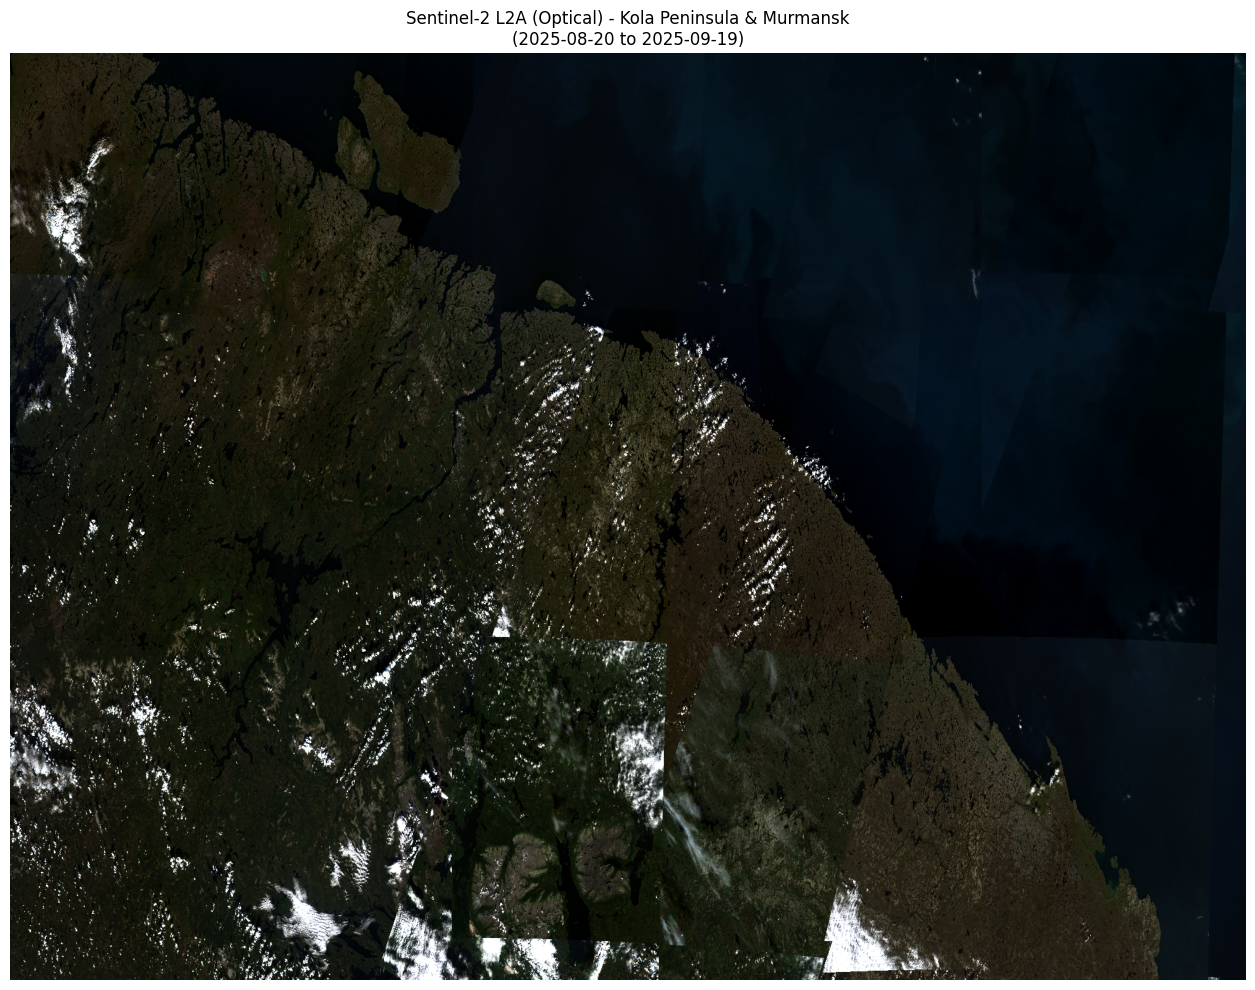


📡 Fetching Sentinel-1 IW (SAR) for Kola Peninsula & Murmansk...
   Time range: 2025-08-20 to 2025-09-19
   Image size: 2000×1500 pixels
✅ Successfully downloaded (1500, 2000)
💾 Saved: Kola_Peninsula_and_Murmansk_S1_20250919_113518.png


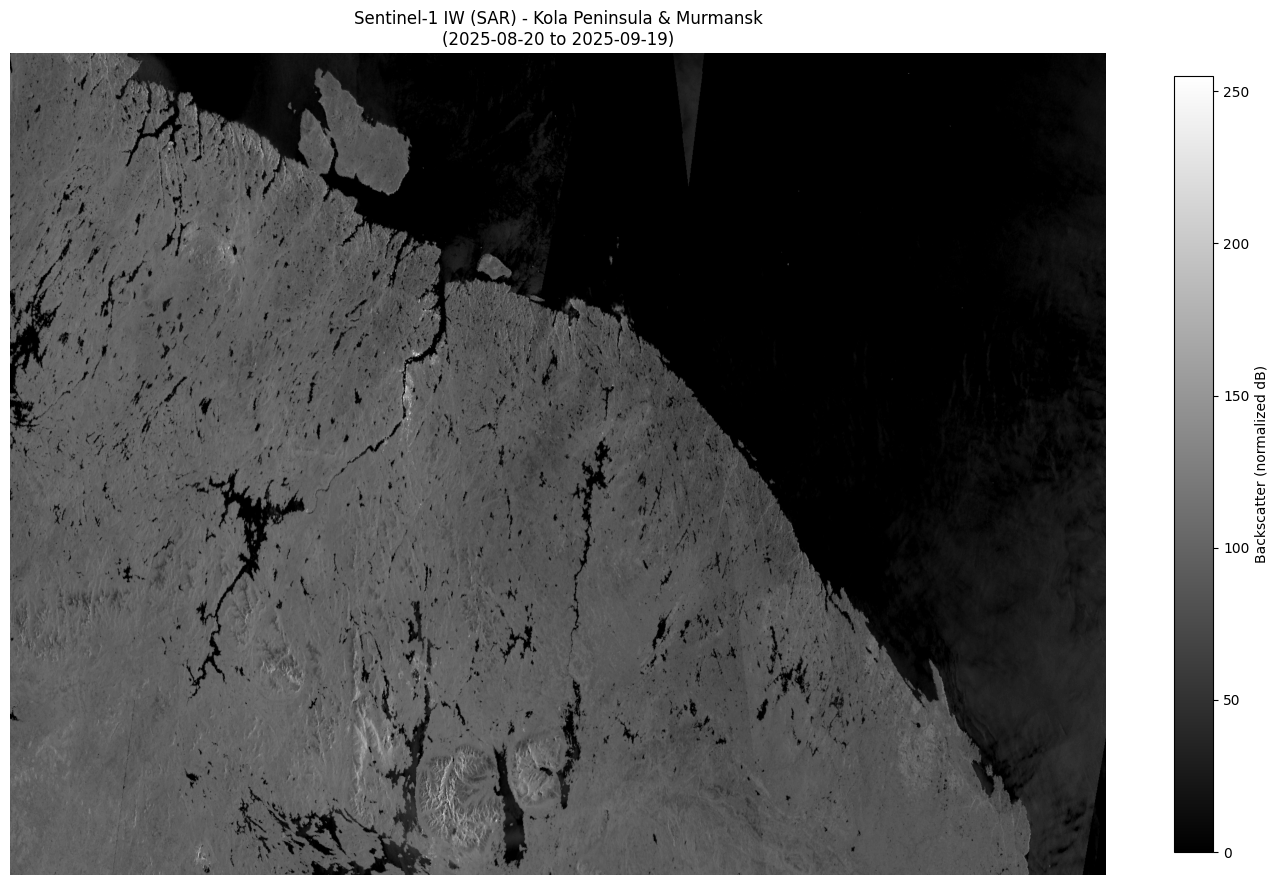


📊 Summary of Arctic Imagery Collection:
  Svalbard Archipelago:
    - Sentinel-2: ✅
    - Sentinel-1: ✅
  Northern Norway:
    - Sentinel-2: ✅
    - Sentinel-1: ✅
  Kola Peninsula & Murmansk:
    - Sentinel-2: ✅
    - Sentinel-1: ✅


In [10]:
#!/usr/bin/env python3
"""
Arctic Satellite Image Fetcher - Sentinel-1 and Sentinel-2
Fetches imagery for Svalbard, Northern Norway, and Kola Peninsula/Murmansk
Uses config.yaml for API credentials
"""

import yaml
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import numpy as np
from sentinelhub import (
    SHConfig,
    DataCollection,
    SentinelHubRequest,
    BBox,
    CRS,
    MimeType,
)

# Define Arctic regions of interest
ARCTIC_REGIONS = {
    'svalbard': {
        'name': 'Svalbard Archipelago',
        'bbox': [10.0, 76.0, 35.0, 81.0],  # [min_lon, min_lat, max_lon, max_lat]
        'description': '🇳🇴 Norwegian Arctic archipelago'
    },
    'north_norway': {
        'name': 'Northern Norway',
        'bbox': [15.0, 68.0, 32.0, 71.5],  # Tromsø to Kirkenes region
        'description': '🇳🇴 Finnmark and northern Troms counties'
    },
    'kola_murmansk': {
        'name': 'Kola Peninsula & Murmansk',
        'bbox': [28.0, 67.5, 42.0, 70.0],  # Kola Peninsula and Murmansk Oblast
        'description': '🇷🇺 Russian Arctic region with naval bases'
    },
    'barents_sea': {
        'name': 'Central Barents Sea',
        'bbox': [20.0, 72.0, 40.0, 76.0],  # Strategic waters between Norway and Russia
        'description': '🌊 Key Arctic maritime corridor'
    },
    'full_arctic': {
        'name': 'Full Arctic Coverage',
        'bbox': [10.0, 65.0, 45.0, 82.0],  # Everything above 65°N from Norway to Russia
        'description': '🗺️ Complete regional overview',
        'size': (3000, 2000)  # Larger size for full coverage
    }
}

def load_config():
    """Load configuration from config.yaml"""
    try:
        with open('config.yaml', 'r') as f:
            return yaml.safe_load(f)
    except FileNotFoundError:
        print("Error: config.yaml not found")
        return None
    except Exception as e:
        print(f"Error loading config: {e}")
        return None

def setup_sentinel_hub():
    """Setup Sentinel Hub configuration from config.yaml"""
    config_data = load_config()
    if not config_data:
        return None
    
    try:
        sh_config = SHConfig()
        sh_config.sh_client_id = config_data['sentinel_hub']['client_id']
        sh_config.sh_client_secret = config_data['sentinel_hub']['client_secret']
        sh_config.sh_token_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
        sh_config.sh_base_url = "https://sh.dataspace.copernicus.eu"
        
        print("✅ Sentinel Hub configuration loaded")
        print(f"   Base URL: {sh_config.sh_base_url}")
        return sh_config
    except KeyError as e:
        print(f"Error: Missing configuration key: {e}")
        return None

def fetch_satellite_image(satellite_type, sh_config, bbox, time_interval, size=(2000, 1500), region_name=""):
    """
    Fetch satellite imagery from Sentinel-1 or Sentinel-2
    
    Args:
        satellite_type: 'S1' for Sentinel-1 SAR or 'S2' for Sentinel-2 optical
        sh_config: Sentinel Hub configuration object
        bbox: Bounding box for the area of interest
        time_interval: Tuple of (start_date, end_date) strings
        size: Image dimensions (width, height) in pixels
        region_name: Name of the region for display purposes
    """
    
    if satellite_type == 'S2':
        # Sentinel-2 optical imagery configuration
        collection = DataCollection.SENTINEL2_L2A.define_from(
            name="sentinel-2-l2a",
            service_url=sh_config.sh_base_url
        )
        
        # True color RGB visualization
        evalscript = """
        //VERSION=3
        function setup() {
            return {
                input: [{bands: ["B02", "B03", "B04"]}],
                output: {bands: 3}
            };
        }
        function evaluatePixel(sample) {
            // Enhanced brightness for Arctic regions
            return [2.5 * sample.B04, 2.5 * sample.B03, 2.5 * sample.B02];
        }
        """
        
        mosaicking_order = "leastCC"  # Least cloud coverage
        label = "Sentinel-2 L2A (Optical)"
        
    elif satellite_type == 'S1':
        # Sentinel-1 SAR imagery configuration
        collection = DataCollection.SENTINEL1_IW.define_from(
            name="sentinel-1-grd",
            service_url=sh_config.sh_base_url
        )
        
        # VV polarization for sea ice and vessel detection
        evalscript = """
        //VERSION=3
        function setup() {
            return {
                input: ["VV"],
                output: {bands: 1}
            };
        }
        function evaluatePixel(sample) {
            // Convert to dB scale and normalize for visualization
            var val = 10 * Math.log(sample.VV) / Math.LN10;
            // Clamp and normalize for typical Arctic SAR values
            val = Math.max(0, (val + 20) / 30);  
            return [val];
        }
        """
        
        mosaicking_order = "mostRecent"  # Most recent acquisition
        label = "Sentinel-1 IW (SAR)"
        
    else:
        print(f"Error: Unknown satellite type '{satellite_type}'. Use 'S1' or 'S2'")
        return None
    
    # Create and execute request
    print(f"\n📡 Fetching {label} for {region_name}...")
    print(f"   Time range: {time_interval[0]} to {time_interval[1]}")
    print(f"   Image size: {size[0]}×{size[1]} pixels")
    
    try:
        request = SentinelHubRequest(
            evalscript=evalscript,
            input_data=[
                SentinelHubRequest.input_data(
                    data_collection=collection,
                    time_interval=time_interval,
                    other_args={"dataFilter": {"mosaickingOrder": mosaicking_order}}
                )
            ],
            responses=[SentinelHubRequest.output_response("default", MimeType.PNG)],
            bbox=bbox,
            size=size,
            config=sh_config,
        )
        
        images = request.get_data()
        
        if images and len(images) > 0:
            image = images[0]
            print(f"✅ Successfully downloaded {image.shape}")
            
            # Display image
            plt.figure(figsize=(14, 10))
            
            # Handle different image dimensions
            if satellite_type == 'S1':
                # Check if image is 2D or 3D
                if len(image.shape) == 2:
                    # 2D array - display directly
                    plt.imshow(image, cmap='gray')
                elif len(image.shape) == 3 and image.shape[2] == 1:
                    # 3D array with single channel - squeeze to 2D
                    plt.imshow(image[:, :, 0], cmap='gray')
                else:
                    # 3D array with multiple channels - use first channel
                    plt.imshow(image[:, :, 0], cmap='gray')
                plt.colorbar(label='Backscatter (normalized dB)', shrink=0.8)
            else:
                # Sentinel-2 RGB image
                plt.imshow(image)
            
            plt.title(f"{label} - {region_name}\n({time_interval[0]} to {time_interval[1]})")
            plt.axis('off')
            plt.tight_layout()
            
            # Save image with region name
            safe_region_name = region_name.replace(" ", "_").replace("&", "and")
            filename = f"{safe_region_name}_{satellite_type}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png"
            plt.savefig(filename, dpi=150, bbox_inches='tight')
            print(f"💾 Saved: {filename}")
            
            plt.show()
            return image
            
        else:
            print(f"❌ No image data received for {label}")
            return None
            
    except Exception as e:
        print(f"❌ Error fetching {label}: {e}")
        if satellite_type == 'S1':
            print("   Note: Sentinel-1 coverage may be limited in some Arctic regions")
        return None

def fetch_region_imagery(region_key, sh_config, satellite_types=['S2', 'S1'], days_back=30):
    """
    Fetch imagery for a specific Arctic region
    
    Args:
        region_key: Key from ARCTIC_REGIONS dict
        sh_config: Sentinel Hub configuration
        satellite_types: List of satellite types to fetch ('S1', 'S2')
        days_back: Number of days to look back for imagery
    """
    if region_key not in ARCTIC_REGIONS:
        print(f"❌ Unknown region: {region_key}")
        print(f"   Available regions: {', '.join(ARCTIC_REGIONS.keys())}")
        return None
    
    region = ARCTIC_REGIONS[region_key]
    region_name = region['name']
    bbox_coords = region['bbox']
    size = region.get('size', (2000, 1500))
    
    print(f"\n{'='*60}")
    print(f"🗺️  {region_name}")
    print(f"    {region['description']}")
    print(f"    Bounds: {bbox_coords[0]:.1f}°E to {bbox_coords[2]:.1f}°E, "
          f"{bbox_coords[1]:.1f}°N to {bbox_coords[3]:.1f}°N")
    print(f"{'='*60}")
    
    # Create bounding box
    bbox = BBox(bbox=bbox_coords, crs=CRS.WGS84)
    
    # Time range
    end_date = datetime.now()
    start_date = end_date - timedelta(days=days_back)
    time_interval = (
        start_date.strftime("%Y-%m-%d"),
        end_date.strftime("%Y-%m-%d")
    )
    
    results = {}
    for sat_type in satellite_types:
        image = fetch_satellite_image(sat_type, sh_config, bbox, time_interval, size, region_name)
        results[sat_type] = image
    
    return results

def main():
    """Main function to fetch Arctic satellite imagery"""
    
    # Setup configuration
    sh_config = setup_sentinel_hub()
    if not sh_config:
        return
    
    print("🛰️  Arctic Satellite Imagery Fetcher")
    print("=" * 60)
    print("Available regions:")
    for key, region in ARCTIC_REGIONS.items():
        print(f"  • {key:15} - {region['name']}")
    print("=" * 60)
    
    # Example: Fetch specific regions
    # You can modify this to fetch the regions you want
    
    # Option 1: Fetch individual regions
    regions_to_fetch = ['svalbard', 'north_norway', 'kola_murmansk']
    
    all_results = {}
    for region_key in regions_to_fetch:
        results = fetch_region_imagery(region_key, sh_config, satellite_types=['S2', 'S1'])
        all_results[region_key] = results
    
    # Option 2: Fetch full Arctic coverage (uncomment to use)
    # full_results = fetch_region_imagery('full_arctic', sh_config, satellite_types=['S2'])
    
    # Summary
    print("\n" + "=" * 60)
    print("📊 Summary of Arctic Imagery Collection:")
    for region_key, results in all_results.items():
        region_name = ARCTIC_REGIONS[region_key]['name']
        if results:
            s2_status = '✅' if results.get('S2') is not None else '❌'
            s1_status = '✅' if results.get('S1') is not None else '❌'
            print(f"  {region_name}:")
            print(f"    - Sentinel-2: {s2_status}")
            print(f"    - Sentinel-1: {s1_status}")
    
    return all_results

# Additional utility function for custom regions
def fetch_custom_region(name, min_lon, min_lat, max_lon, max_lat, sh_config=None, days_back=30):
    """
    Fetch imagery for a custom-defined region
    
    Args:
        name: Name of the custom region
        min_lon, min_lat, max_lon, max_lat: Bounding box coordinates
        sh_config: Sentinel Hub config (will create if None)
        days_back: Number of days to look back
    """
    if sh_config is None:
        sh_config = setup_sentinel_hub()
        if not sh_config:
            return None
    
    bbox = BBox(bbox=[min_lon, min_lat, max_lon, max_lat], crs=CRS.WGS84)
    
    end_date = datetime.now()
    start_date = end_date - timedelta(days=days_back)
    time_interval = (
        start_date.strftime("%Y-%m-%d"),
        end_date.strftime("%Y-%m-%d")
    )
    
    print(f"\n🗺️ Custom Region: {name}")
    print(f"   Bounds: {min_lon:.1f}°E to {max_lon:.1f}°E, {min_lat:.1f}°N to {max_lat:.1f}°N")
    
    s2_image = fetch_satellite_image('S2', sh_config, bbox, time_interval, region_name=name)
    s1_image = fetch_satellite_image('S1', sh_config, bbox, time_interval, region_name=name)
    
    return {'S2': s2_image, 'S1': s1_image}

if __name__ == "__main__":
    main()

In [ ]:
#!/usr/bin/env python3
"""
BarentsWatch Arctic Vessel Tracker
Fetches all vessels and filters for Arctic region (above 65°N)
Uses config.yaml for API credentials
"""

import requests
import json
import yaml
from datetime import datetime

def load_config():
    """Load configuration from config.yaml"""
    config_path = 'config.yaml'
    try:
        with open(config_path, 'r') as f:
            config = yaml.safe_load(f)
        return config
    except FileNotFoundError:
        print(f"Error: {config_path} not found")
        return None
    except Exception as e:
        print(f"Error loading config: {e}")
        return None

def get_access_token():
    """Get access token using credentials from config.yaml"""
    print("Getting access token...")
    
    # Load credentials from config
    config = load_config()
    if not config:
        return None
    
    try:
        CLIENT_ID = config['barentswatch']['client_id']
        CLIENT_SECRET = config['barentswatch']['client_secret']
        SCOPE = config['barentswatch']['scope']
    except KeyError as e:
        print(f"Error: Missing configuration key: {e}")
        print("Ensure config.yaml has barentswatch.client_id, client_secret, and scope")
        return None
    
    token_url = "https://id.barentswatch.no/connect/token"
    
    data = {
        'client_id': CLIENT_ID,
        'client_secret': CLIENT_SECRET,
        'scope': SCOPE,
        'grant_type': 'client_credentials'
    }
    
    headers = {
        'Content-Type': 'application/x-www-form-urlencoded'
    }
    
    try:
        response = requests.post(token_url, data=data, headers=headers)
        response.raise_for_status()
        
        token_data = response.json()
        access_token = token_data['access_token']
        
        print("✅ Got access token from BarentsWatch")
        return access_token
        
    except Exception as e:
        print(f"❌ Token request failed: {e}")
        return None

def get_arctic_vessels(access_token, min_latitude=65.0):
    """Get all vessels and filter for Arctic region (above specified latitude)"""
    
    headers = {
        'Authorization': f'Bearer {access_token}',
        'Accept': 'application/json'
    }
    
    # Get all latest vessel positions
    url = "https://live.ais.barentswatch.no/v1/latest/combined"
    
    print(f"\n🌊 Fetching all vessels from BarentsWatch...")
    
    try:
        response = requests.get(url, headers=headers, timeout=30)
        response.raise_for_status()
        
        all_vessels = response.json()
        
        # Filter for vessels above the minimum latitude
        arctic_vessels = [
            vessel for vessel in all_vessels 
            if vessel.get('latitude', 0) >= min_latitude
        ]
        
        print(f"✅ Found {len(arctic_vessels)} vessels above {min_latitude}°N")
        print(f"   (Out of {len(all_vessels)} total vessels)")
        
        return arctic_vessels
        
    except Exception as e:
        print(f"❌ Error fetching vessels: {e}")
        return []

def display_arctic_vessels(vessels):
    """Display Arctic vessel information"""
    
    if not vessels:
        print("\n❌ No Arctic vessels found")
        return
    
    print(f"\n🚢 Arctic Vessels (sample of first 10):")
    print("=" * 60)
    
    # Show first 10 vessels as sample
    for vessel in vessels[:10]:
        name = vessel.get('name', 'Unknown')
        mmsi = vessel.get('mmsi', 'N/A')
        lat = vessel.get('latitude', 0)
        lon = vessel.get('longitude', 0)
        ship_type = vessel.get('shipType', 'N/A')
        
        print(f"  • {name:25} MMSI:{mmsi:9} Pos:{lat:.2f}°N, {lon:.2f}°E Type:{ship_type}")
    
    if len(vessels) > 10:
        print(f"\n  ... and {len(vessels) - 10} more vessels")
    
    # Show statistics by ship type
    print(f"\n📊 Statistics by vessel type:")
    ship_types = {}
    for vessel in vessels:
        ship_type = vessel.get('shipType', 'Unknown')
        ship_types[ship_type] = ship_types.get(ship_type, 0) + 1
    
    for ship_type, count in sorted(ship_types.items(), key=lambda x: x[1], reverse=True)[:5]:
        print(f"  Type {ship_type}: {count} vessels")

def main():
    """Main function to get Arctic vessels"""
    print("🗺️  BarentsWatch Arctic Vessel Tracker")
    print("Using credentials from config.yaml")
    print("Fetching vessels above 65°N")
    print("=" * 60)
    
    # Step 1: Get access token
    access_token = get_access_token()
    if not access_token:
        print("❌ Failed to get access token. Exiting.")
        return
    
    # Step 2: Get Arctic vessels
    arctic_vessels = get_arctic_vessels(access_token, min_latitude=65.0)
    
    # Step 3: Display results
    display_arctic_vessels(arctic_vessels)
    
    # Optional: Save to JSON file
    if arctic_vessels:
        filename = f"arctic_vessels_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"
        with open(filename, 'w') as f:
            json.dump(arctic_vessels, f, indent=2)
        print(f"\n💾 Data saved to {filename}")

if __name__ == "__main__":
    main()